In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("../data/processed/uci_household_5min.csv", index_col="datetime", parse_dates=True)
print(df.shape)

(415053, 7)


In [2]:
df_test = df.copy()
df_test["is_synthetic_anomaly"] = 0

np.random.seed(42)
n_injections = 40
injection_indices = np.random.choice(len(df_test) - 24, size=n_injections, replace=False)

for start_idx in injection_indices:
    anomaly_type = np.random.choice(["theft_drop", "spike", "voltage_dip"])
    duration = np.random.randint(6, 24)  # 30 min to 2 hours
    end_idx = min(start_idx + duration, len(df_test))

    if anomaly_type == "theft_drop":
        df_test.iloc[start_idx:end_idx, df_test.columns.get_loc("Global_active_power")] *= 0.3
    elif anomaly_type == "spike":
        df_test.iloc[start_idx:end_idx, df_test.columns.get_loc("Global_active_power")] *= 3.5
    elif anomaly_type == "voltage_dip":
        df_test.iloc[start_idx:end_idx, df_test.columns.get_loc("Voltage")] *= 0.85

    df_test.iloc[start_idx:end_idx, df_test.columns.get_loc("is_synthetic_anomaly")] = 1

print(f"Total synthetic anomaly windows: {n_injections}")
print(f"Total anomalous rows: {df_test['is_synthetic_anomaly'].sum()} ({df_test['is_synthetic_anomaly'].sum()/len(df_test)*100:.2f}%)")

Total synthetic anomaly windows: 40
Total anomalous rows: 594 (0.14%)


In [3]:
df_test["hour"] = df_test.index.hour
df_test["pct_change"] = df_test["Global_active_power"].pct_change().fillna(0)
df_test["expected_for_hour"] = df_test.groupby("hour")["Global_active_power"].transform("mean")
df_test["deviation_from_hourly_norm"] = df_test["Global_active_power"] - df_test["expected_for_hour"]

anomaly_features = ["pct_change", "deviation_from_hourly_norm", "Voltage", "Global_reactive_power"]

In [4]:
iso_forest = joblib.load("../src/models/anomaly/isolation_forest.pkl")
scaler = joblib.load("../src/models/anomaly/anomaly_scaler.pkl")

X_scaled = scaler.transform(df_test[anomaly_features])
df_test["iso_pred"] = (iso_forest.predict(X_scaled) == -1).astype(int)

print(df_test["iso_pred"].value_counts())

iso_pred
0    412957
1      2096
Name: count, dtype: int64


In [5]:
precision = precision_score(df_test["is_synthetic_anomaly"], df_test["iso_pred"])
recall = recall_score(df_test["is_synthetic_anomaly"], df_test["iso_pred"])
f1 = f1_score(df_test["is_synthetic_anomaly"], df_test["iso_pred"])
cm = confusion_matrix(df_test["is_synthetic_anomaly"], df_test["iso_pred"])

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Confusion matrix:\n{cm}")

Precision: 0.010
Recall: 0.035
F1-score: 0.016
Confusion matrix:
[[412384   2075]
 [   573     21]]


In [ ]:
df_test.to_csv("../data/processed/synthetic_anomaly_evaluation.csv")

import json
results = {"precision": precision, "recall": recall, "f1_score": f1, "n_injected": n_injections}
with open("../src/models/anomaly/synthetic_eval_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved")

Saved


Caught: 21 rows, Missed: 573 rows


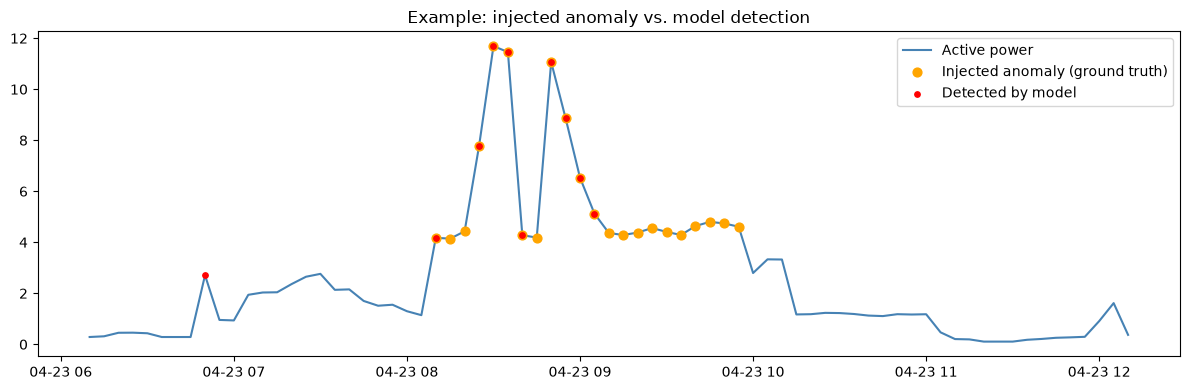

In [6]:
caught = df_test[(df_test["is_synthetic_anomaly"] == 1) & (df_test["iso_pred"] == 1)]
missed = df_test[(df_test["is_synthetic_anomaly"] == 1) & (df_test["iso_pred"] == 0)]

print(f"Caught: {len(caught)} rows, Missed: {len(missed)} rows")

if len(caught) > 0:
    sample_time = caught.index[0]
    window = df_test.loc[sample_time - pd.Timedelta(hours=2): sample_time + pd.Timedelta(hours=4)]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(window.index, window["Global_active_power"], color="steelblue", label="Active power")
    injected = window[window["is_synthetic_anomaly"] == 1]
    detected = window[window["iso_pred"] == 1]
    ax.scatter(injected.index, injected["Global_active_power"], color="orange", s=40, label="Injected anomaly (ground truth)", zorder=3)
    ax.scatter(detected.index, detected["Global_active_power"], color="red", s=15, label="Detected by model", zorder=4)
    ax.legend()
    ax.set_title("Example: injected anomaly vs. model detection")
    plt.tight_layout()
    plt.show()

In [7]:
df_test.to_csv("../data/processed/synthetic_anomaly_evaluation.csv")

import json
results = {"precision": precision, "recall": recall, "f1_score": f1, "n_injected": n_injections}
with open("../src/models/anomaly/synthetic_eval_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved")

Saved


In [ ]:
df_test.to_csv("../data/processed/synthetic_anomaly_evaluation.csv")

import json
results = {"precision": precision, "recall": recall, "f1_score": f1, "n_injected": n_injections}
with open("../src/models/anomaly/synthetic_eval_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved")

Saved
